In [1]:
from InSitu14CO import Site, Firn_Site, Gas, Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

import os.path

from MCEq.core import MCEqRun
from MCEq import config

from tqdm import tqdm

import pandas as pd

import scipy

from scipy import stats

from scipy.io import loadmat
from scipy.interpolate import interp1d

import dynesty

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def smooth_diff(f):
    return np.concatenate(( [(f[1]-f[0])], (f[2:]-f[:-2])/2, [(f[-1]-f[-2])] ), axis=0)

def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(1/lambd[i-1])
        elif x[i]/x[i-1] < np.exp(-1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(-1/lambd[i-1])
    return x

def cum_mat_prod(A,N): # return the first N powers [0:N) of matrix A
    # A can have any shape, as long as the last 2 axes are square
    A_cum = np.ones((N,*A.shape))
    A_cum[0] = np.identity(A.shape[-1])
    for i in tqdm(range(1,N)):
        A_cum[i] = A @ A_cum[i-1]
    return A_cum

In [4]:
lambd = 1.216e-4 # 14C differential decay rate [yr^-1]
ice_eq_file = 'Real_vs_ice_eq_depth.csv'
elev = 3233 #Elevation above sea level [m]
pressure = 65800 # air pressure (Pa)

L = np.array([1, 7e-4]) # Ice Grain Leakage Rates (yr^-1)
Acc = 0.033 # Accumulation rate (m.w.e./yr), if None takes average accumulation rate up to close-off depth
rho_co = 0.833 # density at close off depth? idk
R = 8.314472 # gas constant (J/mol K)
g = 9.82 # gravity (m/s^2)
T = -54 # Temperature (Celsius)
M_air = 28.96e-3 # molar mass of air (kg/mol)
D_0eddy = 2.55e-5 # convective diffusivity const.
H_eddy = 3 #1/e depth of convective layer
age_grid = 'DomeC_age_scale_Apr2023.csv' # sets depth-ice age conversion
tort_file = 'Firn_Model_Tortuosity_DomeC.csv' # inverse tortuosity & diff_m profiles
dt_A = 0.5
dt_D = 0.01
dz_D = 0.25
M_trace = 30e-3 # molar weight [kg/mol]
D_trace_scale = 1.25 * 0.9829926 # free air diffusivity relative to CO2, w/ “sqrt of ratio of reduced masses”

In [5]:
def get_bins(x):
    # returns centers and widths of bins
    x = np.array(x)
    if x.shape[0]==2: # if first axis is length 2, takes index 0 as lower bounds, index 1 as upper bounds
        return (x[0]+x[1])/2, x[1]-x[0]
    else:
        return (x[:-1]+x[1:])/2, np.abs(np.diff(x,axis=0))

In [6]:
sample_file = 'DomeC 14CO data analysis current.xlsx'
pd_DomeC = pd.read_excel(sample_file, '14CO vs depth',
                         header = 2, index_col=0,
                         usecols=[0,1,2,3,5,6], skiprows=[3,16,21,22,23])

z_exp, CO_exp, dCO_exp = pd_DomeC.to_numpy()[:,:3].T
# separate samples into categories
i_samples = [0,3,12,len(z_exp)]
n_samples = ['Firn Sample', 'Borehole 1', 'Borehole 2']

C14_CO = Gas()
DC = Firn_Site(
    gas = C14_CO,
    z_samp = z_exp,
    dz_samp = 20,
    CO = CO_exp,
    CO_err = dCO_exp,
)

In [7]:
# Create an instance of the Propagator Class

months = [
    'January',
    #'February',
    #'March',
    #'April',
    #'May',
    #'June',
    'July',
    #'August',
    #'September',
    #'October',
    #'November',
    #'December',
]

Prop_DC = Propagator(
    site=DC,
)
density_models_DC = [('MSIS00', ('SouthPole', m)) for m in months]

Prop_DC.h

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

In [8]:
# Grid / Bin Ranges & Resolutions

# timespan of analysis [yrs]
t_end = 10000

# time resolutions [yrs]
# CR history time resolution
dt_CR = 20
# atmospheric time resolution
dt_atm = 10

dh_p_TG = 1
dh_p_DC = 1

dz_f_TG = 1
dz_f_DC = 1

In [9]:
def interp_mat(out, grid_in, left=False, right=False): # interpolates from grid_in to out
    # input arrays must have broadcastable shape
    # grid's primary index should be along axis -1
    # left/right control outer bounds : True = 
    
    # slope from 0 to 1 as x passes from lower to upper bound
    slope = ((out[...,:-1 if out.shape[-1]>1 else None]-grid_in[...,:-1])/np.diff(grid_in,axis=-1)).clip(0,1)
    return np.concatenate(
        [(1-left)*(out[...,:1]>=grid_in[...,:1])-slope[...,:1],
         -np.diff(slope, axis=-1),
         slope[...,-1:]-(1-right)*(out[...,-1:]>grid_in[...,-1:])],
        axis=-1)

In [10]:
def bin_average_mat(out_up, out_low, in_low, din):
    S = (out_up-in_low).clip(0,din) - (out_low-in_low).clip(0,din)
    return S/np.sum(S, axis=-1, keepdims=True)

In [11]:
L = np.array([1, 7e-4]) # Ice Grain Leakage Rates (yr^-1)
L

array([1.e+00, 7.e-04])

In [12]:
Res = np.array([1-1e-2, 1e-2])
Res /= np.sum(Res)
Res

array([0.99, 0.01])

In [13]:
COS_partition = np.array(
    [#CO2         CO          CH4
    [0.686307104, 0.31125305, 0.002439846], # neutron
    [0.686307104, 0.31125305, 0.002439846], # neg muon
    [0.686307104, 0.31125305, 0.002439846], # fast muon
])

In [14]:
COS_P = np.array(DC.COS_Production(Prop_DC.h)).T
f = np.array([COS_partition[0,1], 0.04, 0.06])
P = COS_P @ f

In [15]:
dh_f = 0.5
h_f_bins = np.arange(int(DC.h_grid[-1]/dh_f)+1)*dh_f
h_f, dh_f = get_bins(h_f_bins)
h_f_bins

array([  0. ,   0.5,   1. ,   1.5,   2. ,   2.5,   3. ,   3.5,   4. ,
         4.5,   5. ,   5.5,   6. ,   6.5,   7. ,   7.5,   8. ,   8.5,
         9. ,   9.5,  10. ,  10.5,  11. ,  11.5,  12. ,  12.5,  13. ,
        13.5,  14. ,  14.5,  15. ,  15.5,  16. ,  16.5,  17. ,  17.5,
        18. ,  18.5,  19. ,  19.5,  20. ,  20.5,  21. ,  21.5,  22. ,
        22.5,  23. ,  23.5,  24. ,  24.5,  25. ,  25.5,  26. ,  26.5,
        27. ,  27.5,  28. ,  28.5,  29. ,  29.5,  30. ,  30.5,  31. ,
        31.5,  32. ,  32.5,  33. ,  33.5,  34. ,  34.5,  35. ,  35.5,
        36. ,  36.5,  37. ,  37.5,  38. ,  38.5,  39. ,  39.5,  40. ,
        40.5,  41. ,  41.5,  42. ,  42.5,  43. ,  43.5,  44. ,  44.5,
        45. ,  45.5,  46. ,  46.5,  47. ,  47.5,  48. ,  48.5,  49. ,
        49.5,  50. ,  50.5,  51. ,  51.5,  52. ,  52.5,  53. ,  53.5,
        54. ,  54.5,  55. ,  55.5,  56. ,  56.5,  57. ,  57.5,  58. ,
        58.5,  59. ,  59.5,  60. ,  60.5,  61. ,  61.5,  62. ,  62.5,
        63. ,  63.5,

In [16]:
z_f = DC.h_to_z(h_f)

In [17]:
grains_z, leak_open_z, cumuleak_closed_z = DC.Calc_14C_ice(L, P, Prop_DC.h)

In [18]:
C14_open, C14_closed, C14_open_atm, C14_closed_atm, c_gases = DC.Calc_profiles(leak_open_z)

0.01220393180847168
interpolating...


100%|█████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  8.12it/s]


integrating...
  Calculated open and closed profiles for gas
1.2905762195587158


In [19]:
h_past = np.interp(DC.h_to_age(h_f)[:,None] + DC.t_A[None,:], DC.age_grid, DC.h_grid, left=-10)
z_past = np.interp(DC.h_to_age(h_f)[:,None] + DC.t_A[None,:], DC.age_grid, DC.z_grid, left=-10)
h_past.shape

(511, 20087)

In [20]:
f_o = np.interp(z_past, DC.z_grid, DC.s_open)/np.interp(z_past, DC.z_grid, DC.s)

In [21]:
f_c = np.interp(z_past, DC.z_grid, DC.s_closed)/np.interp(z_past, DC.z_grid, DC.s)

Text(0, 0.5, 'Closed Leak Fraction')

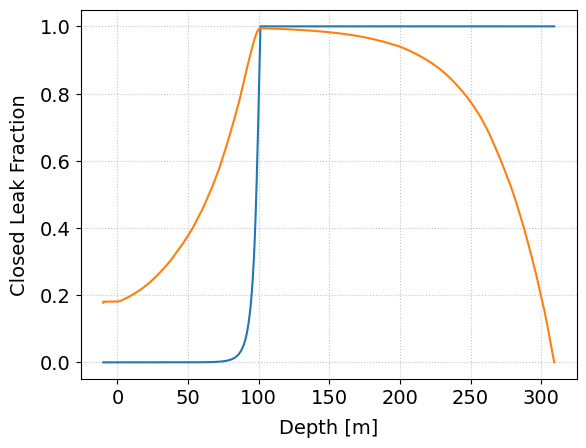

In [22]:
t_int = np.arange(len(DC.t_A))*DC.dt_A
t_int = t_int - t_int[-1]

# fraction of new 14CO at time t which will leak into closed porosity
L_safe = L * (L!=1)
f_c_int = np.cumsum(f_c[:,::-1,None] * (1-L_safe)**t_int[None,::-1,None] * (1-(1-L_safe)**DC.dt_A), axis=1)[:,::-1] * (1-L_safe)**-t_int[None,:,None]
f_c_int += f_c[:,:,None]*(L==1)[None,None,:]

plt.plot(z_past[-1], f_c_int[-1])
plt.xlabel('Depth [m]')
plt.ylabel('Closed Leak Fraction')

$$f_{c\, f,t_A,r}^{\text{int}} = \int_{t_A}^0 f_c(z^{\text{past}}_{f,t'}) (1-\vec{L}_r)^{t'-t_A} (1-(1-\vec{L}_r)^{dt'})$$


$$\hat{A}^{\text{grains}}_{f,t_{CR},p,r} = [\hat{\delta}_{f,t_A,p} (1-\vec{L}_r)^{-t_A+dt_A} e^{\lambda t_A} dt_A] \cdot \hat{\delta}_{t_A,t_{CR}}$$

$$\hat{A}^{\text{closed}}_{f,t_{CR},p,r} = [\hat{\delta}_{f,t_A,p} f_{c\, f,t_A,r}^{\text{int}} e^{\lambda t_A} dt_A] \cdot \hat{\delta}_{t_A,t_{CR}}$$

$$\hat{A}^{\text{direct}}_{f,t_{CR},p,r} = \hat{A}^{\text{grains}} + \hat{A}^{\text{closed}} = [\hat{\delta}_{f,t_A,p} (f_{c\, f,t_A,r}^{\text{int}} + (1-\vec{L}_r)^{-t_A+dt_A}) e^{\lambda t_A} dt_A] \cdot \hat{\delta}_{t_A,t_{CR}}$$

Response = [Interpolate production depths to past ice parcel depths * (closed leak fraction + ) * decay fraction * accumulation timestep] DOT Interpolate CR history to accumulation timesteps]

In [23]:
A_direct = np.zeros((len(h_f), len(Prop_DC.h), len(L)))

for i in tqdm(range(len(t_int))):
    A_direct += interp_mat(h_past[:,i,None], Prop_DC.h[None,:])[:,:,None] * np.exp(lambd * t_int[i]) * (f_c_int[:,i,None,:] + (1-L[None,None,:])**(-t_int[i]+DC.dt_A)) * DC.dt_A

100%|████████████████████████████████████████████████████████████████████████████| 20087/20087 [00:39<00:00, 502.29it/s]


Text(0, 0.5, '$^{14}$CO Concentration [g$^{-1}$]')

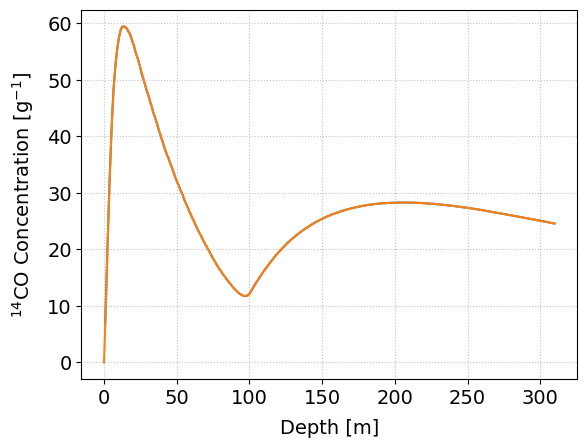

In [24]:
C_dir = np.einsum('fpr, p, r -> f', A_direct, P, Res, optimize=True)

plt.plot(z_f, C_dir)
plt.plot(DC.z_grid, (grains_z + cumuleak_closed_z) @ Res)
plt.xlabel('Depth [m]')
plt.ylabel(r'$^{14}$CO Concentration [g$^{-1}$]')

In [25]:
t_D_cut = DC.h_to_age(DC.h_D[DC.Q])+DC.t_A>=0

h_D_past = np.interp(DC.h_to_age(DC.h_D[:DC.Q])[:,None] + DC.t_A[None,t_D_cut], DC.age_grid, DC.h_grid, left=-10)
h_D_past.shape

(420, 5391)

In [26]:
f_o_D = np.interp(DC.z_D[:DC.Q], DC.z_grid, DC.s_open)/np.interp(DC.z_D[:DC.Q], DC.z_grid, DC.s)

In [27]:
gram_to_ppm = np.interp(DC.z_D[:DC.Q], DC.z_grid, DC.gram_to_ppm)

$$\hat{Leak}_{d,p,r} = \sum_{t_A} U_{g\rightarrow ppm}(z_d) f_o(z_d) \hat{\delta}_{d,t_A,p} (1-\vec{L}_r)^{-t_A} e^{\lambda t_A} (1-(1-\vec{L}_r)^{dt_A})$$

Leak = unit conversion from per gram to ppm * open porosity fraction * Interpolate production depths to past ice parcel depths * unleaked fraction * decay fraction * leak rate * diffusion timestep

In [28]:
Leak_mat = np.zeros((DC.Q, len(Prop_DC.h), len(L)))

t_int_leak = np.arange(len(DC.t_A[t_D_cut]))*DC.dt_A
t_int_leak = t_int_leak - t_int_leak[-1]

for i in tqdm(range(len(t_int_leak))):
    Leak_mat += interp_mat(h_D_past[:,i,None], Prop_DC.h[None,:])[:,:,None] * np.exp(lambd * t_int_leak[i]) * (1-L[None,None,:])**(-t_int_leak[i]) * (1-(1-L[None,None,:])**DC.dt_A)
Leak_mat *= (f_o_D * gram_to_ppm)[:,None,None]

100%|██████████████████████████████████████████████████████████████████████████████| 5391/5391 [00:10<00:00, 517.69it/s]


In [29]:
C14_add = np.concatenate((np.zeros((len(DC.z_D),1)),
                                  DC.dt_D * interp1d(DC.z_grid,
                                      leak_open_z.reshape((len(leak_open_z),-1)) * DC.gram_to_ppm[:,None],
                                      axis=0,
                                  )(DC.z_D)
                                 ), axis=1)

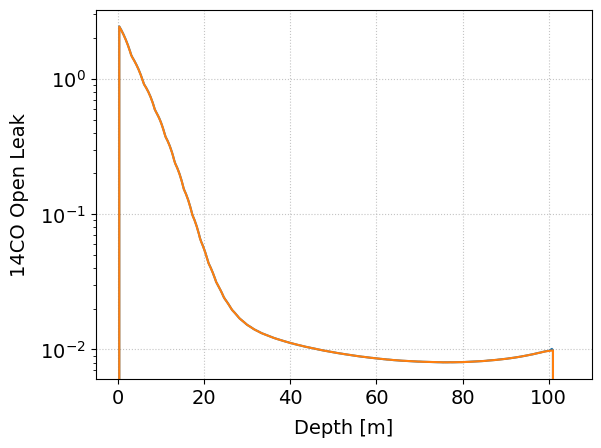

In [30]:
C_add = np.einsum('fpr, p, r -> f', Leak_mat, P, Res, optimize=True)

plt.plot(DC.z_D[:DC.Q], C_add)
#plt.plot(DC.z_grid, leak_open_z[:,0] @ Res * DC.gram_to_ppm * DC.dt_D)
plt.plot(DC.z_D[:DC.Q], C14_add[:DC.Q,1:]@Res / DC.dt_D)
plt.xlabel('Depth [m]')
plt.ylabel('14CO Open Leak')
plt.yscale('log')

Text(0, 0.5, 'Open $^{14}$CO Concentration [10$^{-6}$ ppm]')

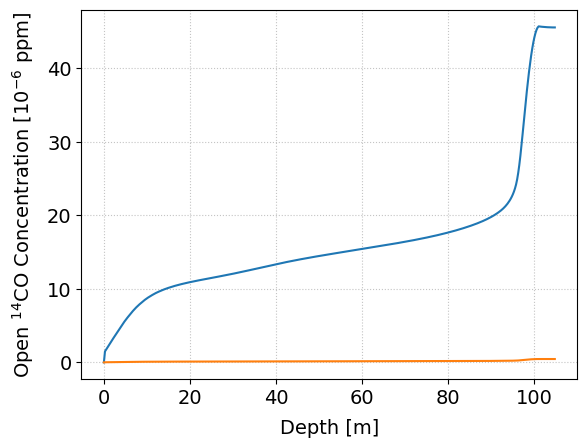

In [31]:
plt.plot(DC.z_D[:DC.Q], np.linalg.inv(np.identity(len(DC.D))-DC.D) @ C_add)
plt.plot(DC.z_D[:DC.Q], c_gases[:DC.Q,1:] @ Res)
#plt.plot(DC.z_D[:DC.Q], np.linalg.inv(np.identity(len(DC.D))-DC.D) @ (C14_add[:DC.Q,1:]@Res))
plt.xlabel('Depth [m]')
plt.ylabel(r'Open $^{14}$CO Concentration [10$^{-6}$ ppm]')

Text(0, 0.5, 'Trapping Rate (Normalized)')

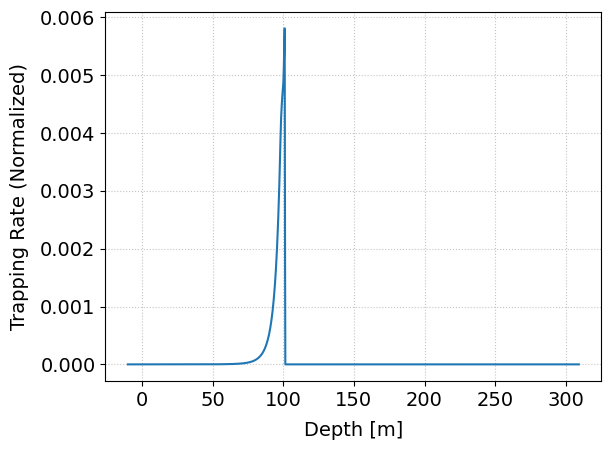

In [32]:
trap = np.interp(z_past, DC.z_grid, DC.trapping_t)
trap_frac = trap / np.sum(trap * DC.dt_A, axis=1, keepdims=True)

plt.plot(z_past[-1], trap_frac[-1])
plt.xlabel('Depth [m]')
plt.ylabel('Trapping Rate (Normalized)')

In [33]:
ppm_to_gram_cl = np.interp(z_f, DC.z_grid, DC.ppm_to_gram_cl)

$$Tr_{f,t_A} = tr(z^{\text{past}}_{f,t_A}) / \int tr(z^{\text{past}}_{f,t'}) dt'$$

$$\hat{Trap}_{f,d} = \sum_{t_A} U_{ppm \rightarrow g}(z_f) \hat{\delta}_{f,t_A,d'} \text{Tr}_{f,t_A} e^{\lambda t_A} dt_A$$

In [34]:
Trap_mat = np.zeros((len(z_f), DC.Q))

for i in tqdm(range(len(t_int))):
    Trap_mat += interp_mat(z_past[:,i,None], DC.z_D[None,:DC.Q]) * np.exp(lambd * t_int[i]) * trap_frac[:,i,None] * DC.dt_A * ppm_to_gram_cl[:,None]

100%|████████████████████████████████████████████████████████████████████████████| 20087/20087 [00:26<00:00, 767.98it/s]


$$\hat{Diff}_{d',d} = (\hat{I}-\hat{D})_{d',d}^{-1} \,dt_D$$

In [35]:
Diff_mat = np.linalg.inv(np.identity(len(DC.D))-DC.D) * DC.dt_D

$$\hat{A}^{\text{trap}}_{f,p,r} = \hat{Trap}_{f,d'} \cdot \hat{Diff}_{d',d} \cdot \hat{Leak}_{d,p,r}$$

In [36]:
A_indirect = np.einsum('fd, dpl -> fpl', Trap_mat @ Diff_mat, Leak_mat, optimize=True)

Text(0, 0.5, 'Trapped $^{14}$CO Concentration [g$^{-1}$]')

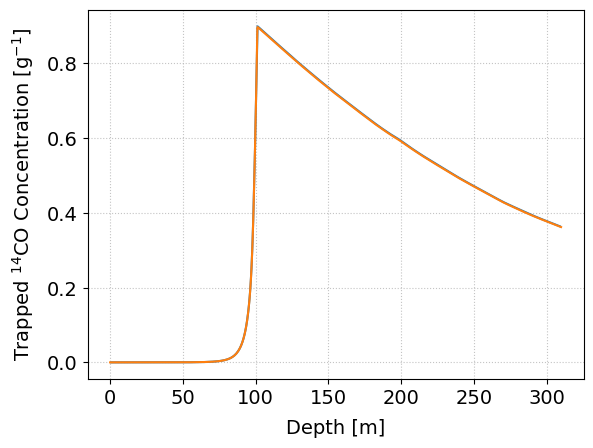

In [37]:
C_ind = np.einsum('fpr, p, r -> f', A_indirect, P, Res, optimize=True)

plt.plot(z_f, C_ind)
plt.plot(DC.z_grid, C14_closed[:,0] @ Res)
plt.xlabel('Depth [m]')
plt.ylabel('Trapped $^{14}$CO Concentration [g$^{-1}$]')

$$\hat{A}_{f,t_{CR},p,r} = \hat{A}^{\text{grains}} + \hat{A}^{\text{closed}} + \hat{A}^{\text{trap}} = [\hat{\delta}_{f,t_A,p} (f_{c\, f,t_A,r}^{\text{int}} + (1-\vec{L}_r)^{-t_A+dt_A}) e^{\lambda t_A} dt_A] \cdot \hat{\delta}_{t_A,t_{CR}} + \sum_{t_A} U_{ppm \rightarrow g}(z_f) \hat{\delta}_{f,t_A,d'} \text{Tr}_{f,t_A} e^{\lambda t_A} dt_A \cdot (\hat{I}-\hat{D})_{d',d}^{-1} \,dt_D \cdot \sum_{t_A} U_{g\rightarrow ppm}(z_d) f_o(z_d) \hat{\delta}_{d,t_A,p} (1-\vec{L}_r)^{-t_A} e^{\lambda t_A} (1-(1-\vec{L}_r)^{dt_A})$$

In [38]:
A_tot = A_direct + A_indirect

Text(0, 0.5, '$^{14}$CO Concentration [g$^{-1}$]')

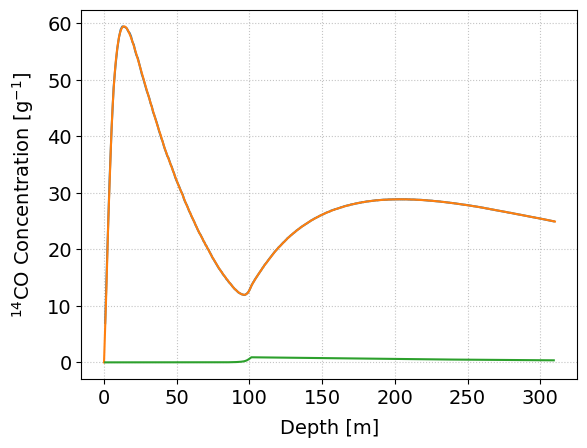

In [39]:
C_pred = np.einsum('fpr, p, r -> f', A_tot, P, Res, optimize=True)

plt.plot(z_f, C_pred)
plt.plot(DC.z_grid, (grains_z + cumuleak_closed_z + C14_closed) @ Res)
plt.plot(z_f, C_ind)
plt.xlabel('Depth [m]')
plt.ylabel('$^{14}$CO Concentration [g$^{-1}$]')